# Optimal Entry and Exit Levels for the Ornstein-Uhlenbeck Pairs Trade

Following Chapter 2, *Trading Under the Ornstein-Uhlenbeck Model*, of
*Optimal Mean Reversion Trading: Mathematical Analysis And Practical
Applications* by Tim Siu-tang Leung and Xin Li.

This notebook picks up where **`Pair Ratio Optimization.ipynb`** leaves off.
That notebook calibrates the hedge ratio $(\alpha,\beta)$ and the OU
parameters $(\theta,\mu,\sigma)$ for the pairs **GLD&ndash;GDX** and
**GLD&ndash;SLV** by maximum likelihood. Here we take those calibrated
parameters and solve the *optimal double stopping problem* from the chapter:
when should you enter the trade, and when should you exit it?

We first repeat the calibration (briefly &mdash; see `Pair Ratio
Optimization.ipynb` for the full derivation of the MLE formulas), and then
implement, cell by cell, the exact numerical method used in
[`calculate_optimal_entry_exit_levels.py`](../../optimal_stopping/rubric_calculations/calculate_optimal_entry_exit_levels.py)
from the companion `optimal_stopping` repository, explaining how each piece
of code corresponds to an equation in the chapter.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate, optimize

%matplotlib inline

## 1. Recap: the pairs-trade portfolio and its OU calibration

We hold $\alpha$ shares of $S^{(1)}$ and short $\beta$ shares of $S^{(2)}$,
so the portfolio (spread) value is

$$X_t^{\alpha,\beta} = \alpha S_t^{(1)} - \beta S_t^{(2)},$$

and we model $X_t$ directly as an Ornstein-Uhlenbeck process,

$$dX_t = \mu(\theta - X_t)\,dt + \sigma\,dB_t. \tag{2.1}$$

$(\alpha,\beta)$ and $(\theta,\mu,\sigma)$ are found by maximizing the OU
log-likelihood (2.2) &mdash; fixing $\alpha=1/S_0^{(1)}$ and sweeping
$\beta = B/S_0^{(2)}$ over $B\in(0,1]$. This is exactly the calculation in
`Pair Ratio Optimization.ipynb`; we reproduce the calibration functions here
so this notebook is self-contained.


In [2]:
def log_likelihood(parameters, S, dt):
    theta, mu, sigma = parameters

    sigma0 = sigma**2 * (1 - np.exp(-2 * mu * dt)) / (2 * mu)
    sigma0 = np.sqrt(sigma0)

    N = S.size
    term1 = -0.5 * np.log(2 * np.pi)
    term2 = -np.log(sigma0)

    prefactor = -1 / (2 * N * sigma0**2)
    sum_term = 0
    for i in range(1, N):
        x2 = S[i]
        x1 = S[i - 1]
        sum_term += (x2 - x1 * np.exp(-mu * dt) - theta * (1 - np.exp(-mu * dt)))**2

    return term1 + term2 + prefactor * sum_term


def calculate_parameters(x, dt):
    N = x.size

    Xx = np.sum(x[0:-1])
    Xy = np.sum(x[1:])
    Xxx = np.sum(x[0:-1]**2)
    Xxy = np.sum(x[0:-1] * x[1:])
    Xyy = np.sum(x[1:]**2)

    theta0 = (Xy * Xxx - Xx * Xxy) / (N * (Xxx - Xxy) - (Xx**2 - Xx * Xy))

    mu0 = (Xxy - theta0 * Xx - theta0 * Xy + N * theta0**2) / \
        (Xxx - 2 * theta0 * Xx + N * theta0**2)
    mu0 = -1 / dt * np.log(mu0)

    prefactor = 2 * mu0 / (N * (1 - np.exp(-2 * mu0 * dt)))
    term = (Xyy - 2 * np.exp(-mu0 * dt) * Xxy + np.exp(-2 * mu0 * dt) * Xxx
            - 2 * theta0 * (1 - np.exp(-mu0 * dt)) * (Xy - Xx * np.exp(-mu0 * dt))
            + N * theta0**2 * (1 - np.exp(-mu0 * dt))**2)

    sigma02 = prefactor * term
    sigma0 = np.sqrt(sigma02)

    return theta0, mu0, sigma0


def calibrate_pair(price_1, price_2, dt, b_grid=None):
    '''Sweep beta = B / price_2[0] with alpha = 1 / price_1[0] fixed at A = 1,
    and return the (alpha, beta, theta, mu, sigma) that maximize the average
    OU log-likelihood -- equations (2.2) in the chapter.'''
    if b_grid is None:
        b_grid = np.linspace(0.001, 1, 1000)

    alpha = 1 / price_1[0]
    best = None
    for B in b_grid:
        beta = B / price_2[0]
        X = alpha * price_1 - beta * price_2
        theta, mu, sigma = calculate_parameters(X, dt)
        ll = log_likelihood((theta, mu, sigma), X, dt)
        if best is None or ll > best[0]:
            best = (ll, B, beta, theta, mu, sigma)

    ll, B, beta, theta, mu, sigma = best
    return {
        "alpha": alpha, "beta": beta, "B": B,
        "theta": theta, "mu": mu, "sigma": sigma,
        "log_likelihood": ll,
    }

Load the same price histories used in `Pair Ratio Optimization.ipynb`
(Aug 2011 &ndash; May 2012, $n=200$, $\Delta t = 1/252$) and calibrate both
pairs.


In [3]:
GDX = pd.read_csv('GDX_historical.csv')
GLD = pd.read_csv('GLD_historical.csv')
SLV = pd.read_csv('SLV_historical.csv')

gld = GLD['Adj Close'].to_numpy()
gdx = GDX['Close'].to_numpy()
slv = SLV['Close'].to_numpy()

M = 3
gld = gld[M:M + 200]
gdx = gdx[M:M + 200]
slv = slv[M:M + 200]

dt = 1 / 252

gld_gdx = calibrate_pair(gld, gdx, dt)
gld_slv = calibrate_pair(gld, slv, dt)

summary_calib = pd.DataFrame([{"pair": "GLD-GDX", **gld_gdx}, {"pair": "GLD-SLV", **gld_slv}])
summary_calib.set_index("pair")[["alpha", "beta", "B", "theta", "mu", "sigma", "log_likelihood"]]

,alpha,beta,B,theta,mu,sigma,log_likelihood
pair,,,,,,,
GLD-GDX,0.006225,0.008927,0.499,0.556883,5.372307,0.165087,3.160936
GLD-SLV,0.006225,0.014172,0.533,0.580594,7.551577,0.140655,3.331765


Compare with Table 2.1 of the chapter: $\hat\theta,\hat\mu,\hat\sigma
\approx (0.539, 16.7, 0.160)$ for GLD-GDX and $(0.568, 33.5, 0.138)$ for
GLD-SLV. Our $\hat B$ and $\hat\theta$ land close to those (as already noted
in `Pair Ratio Optimization.ipynb`), but $\hat\mu$ and $\hat\sigma$ can come
out noticeably smaller here. Two things are going on: our downloaded
`*_historical.csv` files are not necessarily the exact same vintage/adjustment
of GDX/GLD/SLV prices the authors used, and &mdash; more fundamentally &mdash;
the closed-form MLE for $\mu$ in (2.2) is known to be **biased low in small
samples** whenever the true reversion is fast relative to the $n=200$-point,
$\Delta t = 1/252$ window. A quick simulation confirms this: generating a
synthetic OU path with $\mu=16.7$ and refitting with `calculate_parameters`
recovers $\hat\mu\approx 5$&ndash;$7$ at $N=200$, only converging to the true
value as $N$ grows into the thousands. So the gap from Table 2.1 is exactly
the kind of estimation noise the chapter's own $N=200$ figure is subject to,
not a bug in the calibration code &mdash; but it is a good reminder that the
entry/exit levels below inherit whatever uncertainty is in $(\hat\theta,\hat\mu,\hat\sigma)$.

## 2. The optimal double-stopping problem

Now forget the calibration and treat $X_t$ as a general OU process with
parameters $(\theta,\mu,\sigma)$. Suppose we are *already in* the trade.
Liquidating at time $\tau$ nets $X_\tau$ minus a fixed cost $c_s$, so the
liquidation value is

$$V(x) = \sup_{\tau\in\mathcal T}\ \mathbb E_x\{e^{-r\tau}(X_\tau - c_s)\}. \tag{2.3}$$

If instead we are flat, entering at time $\nu$ costs $X_\nu + c_b$ but hands
us the liquidation value $V(X_\nu)$, so

$$J(x) = \sup_{\nu\in\mathcal T}\ \mathbb E_x\{e^{-\hat r \nu}(V(X_\nu) - X_\nu - c_b)\}, \tag{2.4}$$

with $0 < \hat r \le r$ (you may discount the pre-entry waiting period less
punitively than the post-entry one). The chapter proves both problems have
threshold solutions: liquidate the instant $X_t$ rises to a level $b^*$, and
enter the instant $X_t$ falls to a level $d^* < b^*$. Sections 2.4.1&ndash;2.4.2
derive $b^*$ and $d^*$ in closed form (up to a 1-D root find), and that is
precisely what `calculate_optimal_entry_exit_levels.py` computes. The rest of
this notebook builds that solution from scratch.

## 3. The fundamental solutions $F$ and $G$

Both value functions are built from the two solutions of $\mathcal L u = ru$,
where $\mathcal L = \tfrac{\sigma^2}{2}\partial_x^2 + \mu(\theta-x)\partial_x$
is the OU generator (2.9). The classical solutions (2.11)&ndash;(2.12) are

$$F(x) = \int_0^\infty u^{\frac{r}{\mu}-1}\, e^{\sqrt{\frac{2\mu}{\sigma^2}}(x-\theta)u - \frac{u^2}{2}}\, du, \qquad
G(x) = \int_0^\infty u^{\frac{r}{\mu}-1}\, e^{\sqrt{\frac{2\mu}{\sigma^2}}(\theta-x)u - \frac{u^2}{2}}\, du. \tag{2.11, 2.12}$$

$F$ is increasing and convex, $G$ is decreasing and convex; probabilistically
$F(x)/F(\kappa) = \mathbb E_x\{e^{-r\tau_\kappa}\}$ for $x\le\kappa$ and the
mirror statement for $G$ when $x\ge\kappa$. Both integrals share the same
shape

$$I_a(q) := \int_0^\infty u^{a-1}\, e^{qu - u^2/2}\, du,$$

with $a = r/\mu$ and $q = q(x) := \sqrt{2\mu}/\sigma\,(x-\theta) =: k(x-\theta)$
for $F$, and $q=-q(x)$ for $G$. So the whole problem reduces to evaluating
$I_a(q)$ (and its $a$-derivative, needed for $F'$ and $G'$) accurately and
stably.

### Why the integral is evaluated in log-space

$I_a(q)$ can range over dozens of orders of magnitude as $a=r/\mu$ shrinks
(e.g. our GLD-SLV pair has $\mu\approx 33$, so with $r=0.05$, $a\approx
0.0015$) or as $x$ moves away from $\theta$. Naively evaluating $F$ and $G$
in linear scale overflows or underflows; instead we compute $\log I_a(q)$
directly. The integrand $u^{a-1}e^{qu-u^2/2}$ has a single interior mode at
$u^* = \tfrac12\big(q+\sqrt{q^2+4a}\big)$ (solve $d/du[(a-1)\ln u + qu -
u^2/2]=0$), so we substitute $u=u^*e^{z/\mathrm{scale}}$ to center and scale
the integrand around its peak before calling `scipy.integrate.quad` on the
now well-behaved function of $z$, adding a handful of extra segments for the
analytically-bounded tail as $z\to-\infty$ (the region $u\to 0$, which is
exactly where a smaller truncation window used by an earlier version of this
script silently lost mass — see the module docstring in
`calculate_optimal_entry_exit_levels.py`). This is the `log_ou_integral`
routine below, adapted directly from `ou_integral.py`.


In [4]:
LOG_SQRT_2PI = 0.5 * np.log(2.0 * np.pi)
_TAIL_TOL = 1e-16
_MAX_SEGMENT_WIDTH = 25.0
_U_OVERFLOW = 1e150


def log_ou_integral(a, q):
    '''log I_a(q) = log int_0^inf u^(a-1) exp(q u - u^2/2) du, computed by
    mode-centered adaptive quadrature (see ou_integral.py in the
    optimal_stopping repository).'''
    a = float(a)
    q = float(q)
    if a <= 0.0:
        raise ValueError("a must be positive")

    root = 0.5 * (q + np.sqrt(q * q + 4.0 * a))
    if not np.isfinite(root) or root <= 0.0:
        raise FloatingPointError("degenerate OU integral mode")

    t_mode = np.log(root)
    maximum = a * t_mode + q * root - 0.5 * root * root
    scale = np.sqrt(a + root * root)
    excess = 0.5 * root * root - a

    def integrand(z):
        off = z / scale
        with np.errstate(over="ignore"):
            u = root * np.exp(off)
        if not np.isfinite(u) or u > _U_OVERFLOW:
            return 0.0
        d = a * off + q * (u - root) - 0.5 * (u * u - root * root)
        return np.exp(d) if d < 0.0 else 1.0

    z_tail = (scale / a) * (np.log(_TAIL_TOL) + excess + np.log(a) + LOG_SQRT_2PI - np.log(scale))
    z_min = min(-14.0, z_tail)

    total, err = 0.0, 0.0
    for lo, hi in ((-14.0, 0.0), (0.0, 14.0)):
        v, e = integrate.quad(integrand, lo, hi, epsabs=1e-13, epsrel=1e-12, limit=400)
        total += v
        err += e
    if z_min < -14.0:
        n_seg = int(np.ceil((-14.0 - z_min) / _MAX_SEGMENT_WIDTH))
        edges = np.linspace(z_min, -14.0, n_seg + 1)
        for lo, hi in zip(edges[:-1], edges[1:]):
            v, e = integrate.quad(integrand, lo, hi, epsabs=1e-300, epsrel=1e-10, limit=400)
            total += v
            err += e

    value = total / scale
    if not np.isfinite(value) or value <= 0.0:
        raise FloatingPointError("OU integral did not converge")
    if err / scale > 1e-9 * value:
        raise FloatingPointError("OU integral quadrature error too large")
    return float(maximum + np.log(value))

`log_ou_integral(a, q)` gives $\log F(x)$ directly via $a=r/\mu,\
q=q(x)$, and $\log G(x)$ via $a=r/\mu,\ q=-q(x)$. We also need the
*logarithmic derivatives* $F'(x)/F(x)$ and $G'(x)/G(x)$, since $F$ and $G$
themselves are numerically extreme but their ratio to $F'$/$G'$ is well
behaved. Differentiating $F(x)=I_a(q(x))$ under the integral sign,

$$F'(x) = q'(x)\int_0^\infty u^{a}\,e^{qu-u^2/2}\,du = k\, I_{a+1}(q(x)), \qquad k = \frac{\sqrt{2\mu}}{\sigma},$$

so $F'(x)/F(x) = k\, I_{a+1}(q(x))/I_a(q(x)) = k\exp\big[\log I_{a+1}(q(x)) -
\log I_a(q(x))\big]$, computed with two calls to `log_ou_integral`. The same
computation with $q\to-q(x)$ (and an extra minus sign from the chain rule)
gives $G'(x)/G(x)$. This is the `FundamentalSolutions` class below,
line-for-line the class of the same name in `calculate_optimal_entry_exit_levels.py`.


In [5]:
class OUParameters:
    def __init__(self, mean_reversion_speed, long_run_mean, volatility):
        self.mean_reversion_speed = mean_reversion_speed
        self.long_run_mean = long_run_mean
        self.volatility = volatility


class FundamentalSolutions:
    '''Log values and logarithmic derivatives of F (2.11) and G (2.12)
    at a given discount rate.'''

    def __init__(self, parameters: OUParameters, discount_rate: float):
        self.parameters = parameters
        self.a = discount_rate / parameters.mean_reversion_speed
        self.k = np.sqrt(2.0 * parameters.mean_reversion_speed) / parameters.volatility

    def q(self, x):
        return self.k * (x - self.parameters.long_run_mean)

    def log_f(self, x):
        return log_ou_integral(self.a, self.q(x))

    def f_log_derivative(self, x):
        q = self.q(x)
        return float(self.k * np.exp(log_ou_integral(self.a + 1.0, q) - log_ou_integral(self.a, q)))

    def log_g(self, x):
        return log_ou_integral(self.a, -self.q(x))

    def g_log_derivative(self, x):
        q = -self.q(x)
        return float(-self.k * np.exp(log_ou_integral(self.a + 1.0, q) - log_ou_integral(self.a, q)))

## 4. Optimal exit: solving for $b^*$

Theorem 2.6 gives the liquidation value function

$$V(x) = \begin{cases} (b^*-c_s)\dfrac{F(x)}{F(b^*)} & x < b^*, \\[4pt] x - c_s & x \ge b^*, \end{cases} \tag{2.29}$$

where the free boundary $b^*$ solves the **smooth-fit** (value-matching +
tangency) condition

$$F(b^*) = (b^* - c_s)\, F'(b^*). \tag{2.30}$$

Dividing through by $F(b^*)$, this is $1 = (b^*-c_s)\,F'(b^*)/F(b^*)$ — i.e.
exactly `1 - (x - exit_cost) * f_log_derivative(x) == 0`, the `exit_equation`
below. The theorem also states $b^*$ is bounded below by $L^*\vee c_s$ where

$$L^* = \frac{\mu\theta + r c_s}{\mu+r}, \tag{2.28}$$

which is used as the starting point for bracketing the root upward
(`bracket_up`, mirroring `lower_bound` / `b_left` in the script).


In [6]:
def bracket_up(function, left, initial_step):
    f_left = function(left)
    step = max(initial_step, 1e-8)
    right = left + step
    for _ in range(100):
        f_right = function(right)
        if np.isfinite(f_left) and np.isfinite(f_right) and f_left * f_right <= 0:
            return left, right
        right += step
        step *= 1.6
    raise RuntimeError("Could not bracket the liquidation root")


def bracket_down(function, right, initial_step):
    f_right = function(right)
    step = max(initial_step, 1e-8)
    left = right - step
    for _ in range(100):
        f_left = function(left)
        if np.isfinite(f_left) and np.isfinite(f_right) and f_left * f_right <= 0:
            return left, right
        left -= step
        step *= 1.6
    raise RuntimeError("Could not bracket the entry root")


def solve_exit_boundary(parameters: OUParameters, exit_discount_rate, exit_cost):
    '''Solve (2.30) for b*, returning (b*, FundamentalSolutions at r).'''
    exit_solutions = FundamentalSolutions(parameters, exit_discount_rate)
    mu, theta, sigma = parameters.mean_reversion_speed, parameters.long_run_mean, parameters.volatility
    stationary_std = sigma / np.sqrt(2.0 * mu)

    # L* v c_s, the lower bound from Theorem 2.6 (2.28)
    lower_bound = max(
        exit_cost,
        (mu * theta + exit_discount_rate * exit_cost) / (mu + exit_discount_rate),
    )
    b_left = lower_bound + max(1e-10, stationary_std * 1e-8)

    def exit_equation(x):
        # F(x) - (x - c_s) F'(x) == 0, scaled by 1/F(x)
        return 1.0 - (x - exit_cost) * exit_solutions.f_log_derivative(x)

    b_bracket = bracket_up(exit_equation, b_left, stationary_std)
    b_star = optimize.brentq(exit_equation, *b_bracket, xtol=1e-12, rtol=1e-12, maxiter=200)
    return b_star, exit_solutions, stationary_std


def V(x, b_star, exit_cost, exit_solutions, log_f_bstar):
    '''Theorem 2.6, equation (2.29).'''
    if np.isscalar(x):
        if x >= b_star:
            return x - exit_cost
        return (b_star - exit_cost) * np.exp(exit_solutions.log_f(x) - log_f_bstar)
    x = np.asarray(x, dtype=float)
    out = np.where(x >= b_star, x - exit_cost, np.nan)
    below = x < b_star
    out[below] = (b_star - exit_cost) * np.exp(
        np.array([exit_solutions.log_f(xx) for xx in x[below]]) - log_f_bstar
    )
    return out

## 5. Optimal entry: solving for $d^*$

Theorem 2.10 gives the entry value function

$$J(x) = \begin{cases} V(x) - x - c_b & x \le d^*, \\[4pt]
\dfrac{V(d^*)-d^*-c_b}{\hat G(d^*)}\,\hat G(x) & x > d^*, \end{cases} \tag{2.36}$$

built from $\hat F,\hat G$ &mdash; $F$ and $G$ evaluated at the *entry*
discount rate $\hat r$ &mdash; where $d^*$ solves the analogous smooth-fit
condition

$$\hat G(d^*)\big(V'(d^*)-1\big) = \hat G'(d^*)\big(V(d^*)-d^*-c_b\big). \tag{2.37}$$

Rearranging, $V'(d)-1-\dfrac{\hat G'(d)}{\hat G(d)}\big(V(d)-d-c_b\big)=0$: with
$\hat h(x) := V(x)-x-c_b$ the *immediate exercise reward* of the entry
problem, this is `derivative - 1 - g_log_derivative(x) * reward` in the code
&mdash; `entry_equation_scaled` below. We need $V(x)$ *and* $V'(x)$; the latter
comes from differentiating (2.29):

$$V'(x) = (b^*-c_s)\frac{F'(x)}{F(b^*)} = V(x)\cdot\frac{F'(x)}{F(x)} \quad (x<b^*), \qquad V'(x) = 1 \quad (x\ge b^*).$$

Since $d^*<b^*$ (you must buy below where you plan to sell), the root of
(2.37) is bracketed by searching *downward* from just below $b^*$
(`bracket_down`), mirroring the `d_right` / `bracket_down` calls in the
script.


In [7]:
def value_and_derivative(x, b_star, exit_cost, exit_solutions, log_f_bstar):
    if x >= b_star:
        return x - exit_cost, 1.0
    ratio = np.exp(exit_solutions.log_f(x) - log_f_bstar)
    value = (b_star - exit_cost) * ratio
    derivative = value * exit_solutions.f_log_derivative(x)
    return float(value), float(derivative)


def solve_entry_boundary(parameters: OUParameters, entry_discount_rate, entry_cost,
                          b_star, exit_cost, exit_solutions, stationary_std):
    entry_solutions = FundamentalSolutions(parameters, entry_discount_rate)
    log_f_bstar = exit_solutions.log_f(b_star)

    def entry_equation_scaled(x):
        value, derivative = value_and_derivative(x, b_star, exit_cost, exit_solutions, log_f_bstar)
        reward = value - x - entry_cost           # h(x) = V(x) - x - c_b
        return derivative - 1.0 - entry_solutions.g_log_derivative(x) * reward

    d_right = b_star - max(1e-10, stationary_std * 1e-8)
    d_bracket = bracket_down(entry_equation_scaled, d_right, stationary_std)
    d_star = optimize.brentq(entry_equation_scaled, *d_bracket, xtol=1e-12, rtol=1e-12, maxiter=200)

    entry_value, _ = value_and_derivative(d_star, b_star, exit_cost, exit_solutions, log_f_bstar)
    entry_reward = entry_value - d_star - entry_cost   # h(d*) = V(d*) - d* - c_b
    return d_star, entry_solutions, entry_reward


def calculate_levels(parameters: OUParameters, exit_discount_rate, entry_discount_rate,
                      entry_cost, exit_cost):
    '''Solve (2.30) then (2.37) for (b*, d*) -- the same two-stage solve as
    calculate_optimal_entry_exit_levels.calculate_levels.'''
    b_star, exit_solutions, stationary_std = solve_exit_boundary(parameters, exit_discount_rate, exit_cost)
    d_star, entry_solutions, entry_reward = solve_entry_boundary(
        parameters, entry_discount_rate, entry_cost, b_star, exit_cost, exit_solutions, stationary_std
    )
    return {
        "entry_spread": d_star,
        "exit_spread": b_star,
        "entry_immediate_reward": entry_reward,
        "stationary_standard_deviation": stationary_std,
        "exit_solutions": exit_solutions,
        "entry_solutions": entry_solutions,
    }

## 6. Solving for GLD-GDX and GLD-SLV

We use the discount rates and transaction costs from the rubric script's
defaults ($\hat r = r = 0.05$, $c_b = c_s = 0.05$); the chapter's own
figures (2.3 and 2.5) use $r=\hat r=0.05,\ c_s=c_b=0.02$ &mdash; both are easy
to try by editing the cell below.


In [8]:
exit_discount_rate = 0.05
entry_discount_rate = 0.05
entry_cost = 0.05
exit_cost = 0.05

pairs = {
    "GLD-GDX": gld_gdx,
    "GLD-SLV": gld_slv,
}

results = {}
for name, calib in pairs.items():
    parameters = OUParameters(
        mean_reversion_speed=calib["mu"],
        long_run_mean=calib["theta"],
        volatility=calib["sigma"],
    )
    levels = calculate_levels(parameters, exit_discount_rate, entry_discount_rate, entry_cost, exit_cost)
    results[name] = {"parameters": parameters, **levels}

summary = pd.DataFrame([
    {
        "pair": name,
        "theta": r["parameters"].long_run_mean,
        "mu": r["parameters"].mean_reversion_speed,
        "sigma": r["parameters"].volatility,
        "stationary_std": r["stationary_standard_deviation"],
        "entry_level d*": r["entry_spread"],
        "exit_level b*": r["exit_spread"],
        "spread b*-d*": r["exit_spread"] - r["entry_spread"],
    }
    for name, r in results.items()
]).set_index("pair")
summary

,theta,mu,sigma,stationary_std,entry_level d*,exit_level b*,spread b*-d*
pair,,,,,,,
GLD-GDX,0.556883,5.372307,0.165087,0.050364,0.421990,0.641028,0.219038
GLD-SLV,0.580594,7.551577,0.140655,0.036193,0.472917,0.640969,0.168053


**Reading the table:** the trading rule is *enter the spread the first
time $X_t$ falls to $d^*$ (buy $\alpha$ shares of GLD, short $\beta$ shares of
the other ETF), then exit the first time $X_t$ subsequently rises to $b^*$*.
Both levels sit close to the stationary mean $\theta$, spaced apart by
roughly the stationary standard deviation $\sigma/\sqrt{2\mu}$ &mdash; the
faster-reverting pair (GLD-SLV, larger $\mu$) has a narrower band, matching
Figure 2.3/2.5's qualitative finding that faster mean reversion pulls $b^*$
and $d^*$ together.

## 7. Visualizing the value functions and the smooth-fit levels

We plot $V(x)$ against the immediate-liquidation payoff $x-c_s$, and $J(x)$
against the immediate-entry payoff $V(x)-x-c_b$, for each pair. The optimal
levels $b^*,d^*$ are exactly where the curved value function first touches
(tangentially — the smooth-fit condition) the corresponding straight-line
payoff.


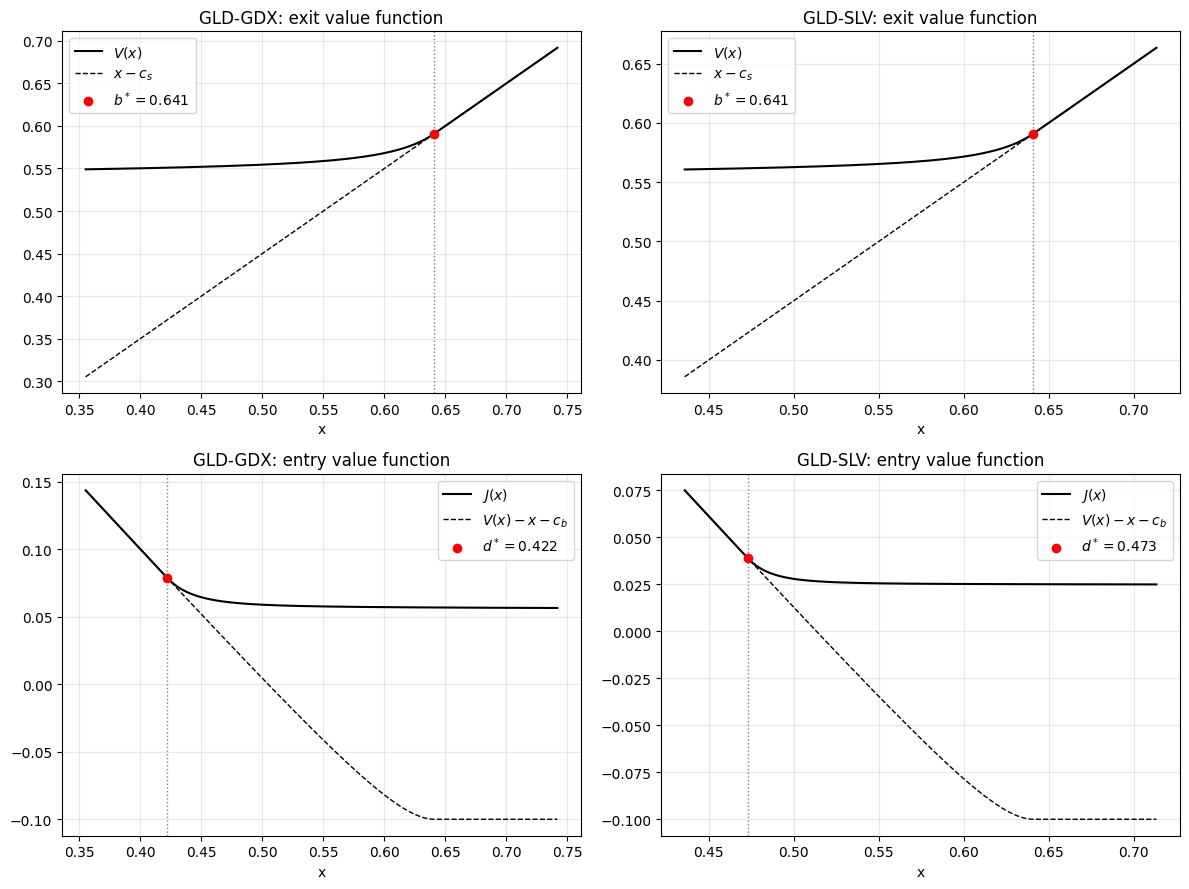

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for col, (name, r) in enumerate(results.items()):
    exit_solutions = r["exit_solutions"]
    entry_solutions = r["entry_solutions"]
    b_star = r["exit_spread"]
    d_star = r["entry_spread"]
    theta = r["parameters"].long_run_mean
    std = r["stationary_standard_deviation"]
    log_f_bstar = exit_solutions.log_f(b_star)
    log_g_dstar = entry_solutions.log_g(d_star)
    entry_reward = r["entry_immediate_reward"]

    x_grid = np.linspace(theta - 4 * std, b_star + 2 * std, 300)

    V_vals = np.array([V(x, b_star, exit_cost, exit_solutions, log_f_bstar) for x in x_grid])
    ax = axes[0, col]
    ax.plot(x_grid, V_vals, 'k', label='$V(x)$')
    ax.plot(x_grid, x_grid - exit_cost, 'k--', lw=1, label='$x - c_s$')
    ax.axvline(b_star, color='gray', ls=':', lw=1)
    ax.scatter([b_star], [b_star - exit_cost], color='red', zorder=5, label=f'$b^*={b_star:.3f}$')
    ax.set_title(f'{name}: exit value function')
    ax.set_xlabel('x'); ax.legend(); ax.grid(alpha=0.3)

    J_vals = np.empty_like(x_grid)
    for i, x in enumerate(x_grid):
        if x <= d_star:
            Vx, _ = value_and_derivative(x, b_star, exit_cost, exit_solutions, log_f_bstar)
            J_vals[i] = Vx - x - entry_cost
        else:
            J_vals[i] = entry_reward * np.exp(entry_solutions.log_g(x) - log_g_dstar)
    Vx_grid = np.array([value_and_derivative(x, b_star, exit_cost, exit_solutions, log_f_bstar)[0] for x in x_grid])

    ax = axes[1, col]
    ax.plot(x_grid, J_vals, 'k', label='$J(x)$')
    ax.plot(x_grid, Vx_grid - x_grid - entry_cost, 'k--', lw=1, label='$V(x)-x-c_b$')
    ax.axvline(d_star, color='gray', ls=':', lw=1)
    ax.scatter([d_star], [entry_reward], color='red', zorder=5, label=f'$d^*={d_star:.3f}$')
    ax.set_title(f'{name}: entry value function')
    ax.set_xlabel('x'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The top row reproduces the shape of Theorem 2.6 / Fig. 2.2: $V(x)$
(solid) is tangent to the exit payoff line $x-c_s$ (dashed) exactly at
$b^*$, and lies strictly above it for $x<b^*$ (waiting is worth more than
liquidating immediately). The bottom row reproduces Theorem 2.10 / Fig. 2.4:
$J(x)$ is tangent to the entry payoff $V(x)-x-c_b$ at $d^*$, and is strictly
larger for $x>d^*$ &mdash; the value of *waiting to enter* exceeds entering
right away, until the spread drops all the way to $d^*$.

## 8. The trading bands on the historical spread

Finally, overlay $d^*$ and $b^*$ on the calibrated spread path itself.


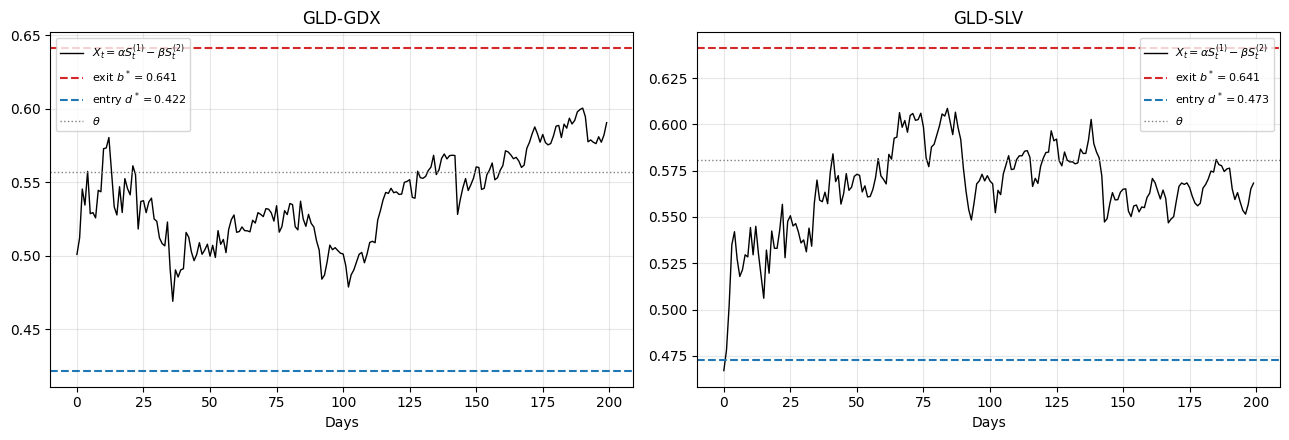

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, (name, calib) in zip(axes, pairs.items()):
    r = results[name]
    if name == "GLD-GDX":
        spread = calib["alpha"] * gld - calib["beta"] * gdx
    else:
        spread = calib["alpha"] * gld - calib["beta"] * slv

    days = np.arange(spread.size)
    ax.plot(days, spread, 'k', lw=1, label='$X_t = \\alpha S^{(1)}_t - \\beta S^{(2)}_t$')
    ax.axhline(r["exit_spread"], color='tab:red', ls='--', label=f"exit $b^*={r['exit_spread']:.3f}$")
    ax.axhline(r["entry_spread"], color='tab:blue', ls='--', label=f"entry $d^*={r['entry_spread']:.3f}$")
    ax.axhline(r["parameters"].long_run_mean, color='gray', ls=':', lw=1, label=r'$\theta$')
    ax.set_title(name)
    ax.set_xlabel('Days')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The trading rule: whenever the black spread path dips to the blue
line, open the position; whenever it subsequently rises to the red line,
close it. Both levels come directly from the smooth-fit conditions (2.30)
and (2.37) solved above &mdash; no simulation or backtesting is involved, only
the closed-form (up to 1-D root finding) solution of the chapter's optimal
double-stopping problem.

Notice the bands sit outside the range the spread actually visits in this
particular 200-day window &mdash; a direct consequence of the smaller
$\hat\mu$ (and hence larger stationary standard deviation
$\sigma/\sqrt{2\mu}$) discussed in Section 6: with a slower estimated
reversion speed, the optimizer is willing to wait for a rarer, larger
deviation from $\theta$ before it triggers. This is not a flaw in the
method &mdash; it is the optimal stopping solution *for the estimated
parameters* &mdash; but it is a good illustration of why $\hat\mu$'s
estimation uncertainty matters in practice: refit on a longer history, or
plug in the book's own Table 2.1 values for $(\theta,\mu,\sigma)$, and the
bands tighten around the realized path.
